# Физически информированная нейронная сеть для оценки перепада давления при сужении сосуда

## 1. Подготовка окружения и загрузка данных

### 1.1. Импорт библиотек и модулей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import random
import os
import joblib
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

### 1.2. Устанавливаем seed для всех источников случайности, чтобы результаты всегда были одни и те же

In [2]:
def reset_all_seeds(seed=24):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


### 1.3. Загрузка данных

In [3]:
df = pd.read_csv('../data/data4_2.csv',sep=',')

In [4]:
# df = df[df['Degree of stenosis'] < 0.65]
df['Degree of stenosis'].unique()

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [5]:
df.head()

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference
0,30,5.0,0.0,1.0,8.314286
1,50,5.0,0.0,1.0,4.813714
2,100,5.0,0.0,1.0,2.422286
3,200,5.0,0.0,1.0,1.201500
4,300,5.0,0.0,1.0,0.804857


### 1.4 Формирование признаков и целевой переменной

Параметры:
* `Re` - число Рейнольдса;
* `Stenosis length/Radius` - соотношение длины пораженного участка сосуда к самому узкому диаметру;
* `Degree of stenosis` - степень стеноза;
* `Asymmetry` - степень ассиметрии, где 0 - полностью симметричный сосуд, 1 - полностью ассиметричный сосуд;
* `Pressure difference` - нормированный перепад давления, который вычисляется как разница давления до сужения и после;
* `mu` - динамическая вязкость;

In [6]:
REF = 1
eps = 1e-6
mu = 1.0

mu_tensor = torch.tensor(mu, dtype=torch.float32)

y = df['Pressure difference'].values / REF
re = np.log(df['Re'])
Lr = df['Stenosis length/Radius']
Ds = df['Degree of stenosis']
asym = df['Asymmetry']

### 1.5 Разбиение на обучающую и тестовую выборки

In [7]:
y_log = np.log1p(y).reshape(-1, 1)
X_np = np.stack([re, Lr, Ds, asym], axis=1).astype(np.float32)

# X_np = pd.concat([re, Lr, Ds, asym], axis=1).to_numpy(dtype=np.float32)
# X_t  = torch.from_numpy(X_np).requires_grad_(True)  # перевод NumPy-массив в тензор PyTorch + включает отслеживание градиентов по этому тензору
# stratify_key = df['Degree of stenosis']

# X_train, X_test, y_train_log, y_test_log = train_test_split(
#     X_np,
#     y_log,
#     test_size=0.2,
#     random_state=42,
#     stratify=stratify_key
# )
X_train, X_test, y_train_log, y_test_log = train_test_split(X_np, y_log, test_size=0.2, random_state=42)

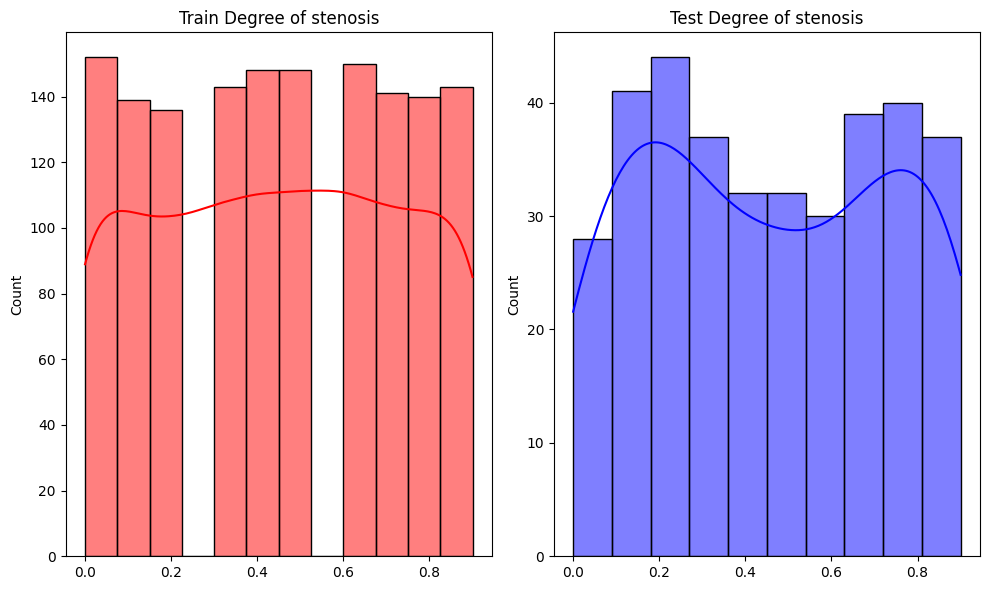

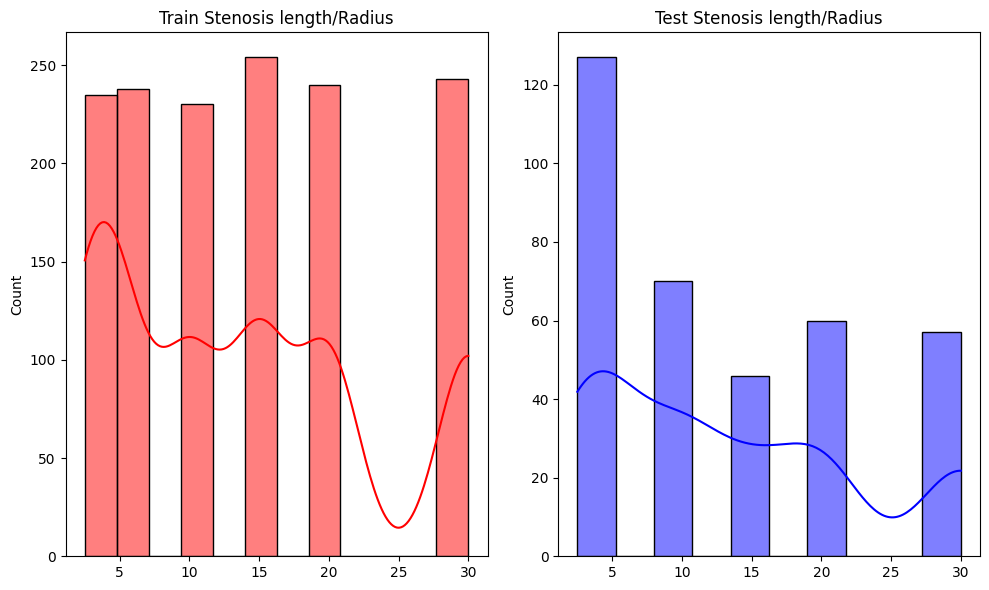

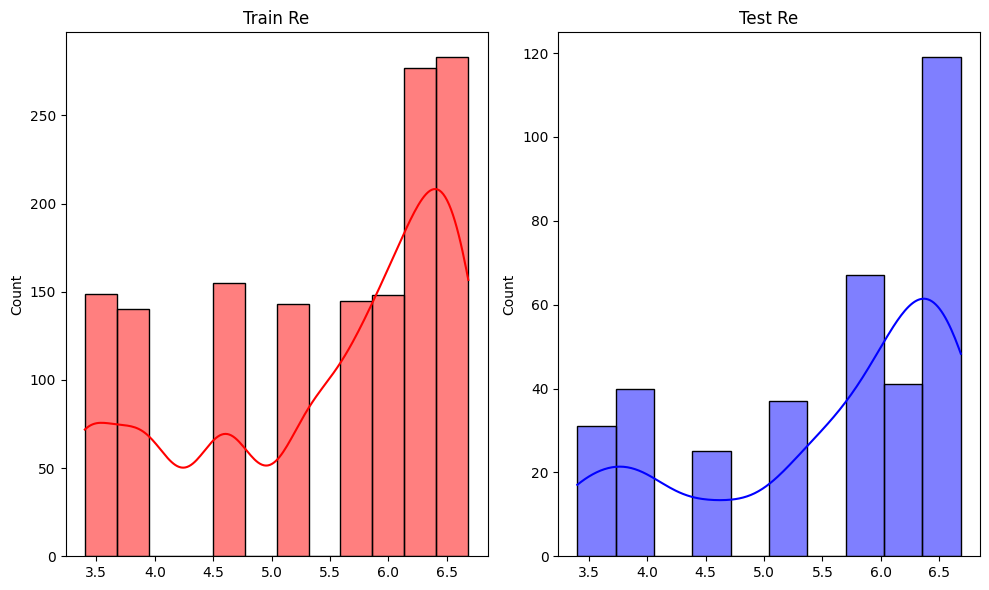

In [8]:
def train_test_plot_np(train, test, col_idx, col_name):
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(train[:, col_idx], kde=True, color='red')
    plt.title(f'Train {col_name}')

    plt.subplot(1, 2, 2)
    sns.histplot(test[:, col_idx], kde=True, color='blue')
    plt.title(f'Test {col_name}')

    plt.tight_layout()
    plt.show()

train_test_plot_np(X_train, X_test, 2, 'Degree of stenosis')
train_test_plot_np(X_train, X_test, 1, 'Stenosis length/Radius')
train_test_plot_np(X_train, X_test, 0, 'Re')

In [9]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_re": [],
    "test_re": [],
    "train_r2": [],
    "test_r2": []
}

history_no_phys = {
    "train_loss": [],
    "test_loss": [],
    "train_re": [],
    "test_re": [],
    "train_r2": [],
    "test_r2": []
}

### 1.6. Масштабирование данных

In [10]:
### масштабирование признаков
scaler_X = MinMaxScaler()

# скейлерные значения
X_train_scaled_np = scaler_X.fit_transform(X_train) # массив numpy
X_test_scaled_np = scaler_X.transform(X_test) # массив numpy

X_train_scaled = torch.as_tensor(X_train_scaled_np, dtype=torch.float32) # перевод массива numpy в тензор pytorch
X_test_scaled = torch.as_tensor(X_test_scaled_np, dtype=torch.float32) # перевод массива numpy в тензор pytorch

# немасштабированные тензоры
X_train_unscaled = torch.as_tensor(X_train, dtype=torch.float32) # перевод массива numpy в тензор pytorch
X_test_unscaled = torch.as_tensor(X_test, dtype=torch.float32) # перевод массива numpy в тензор pytorch

In [11]:
### масштабирование целевой переменной
scaler_y = MinMaxScaler()

# массив numpy
y_train_scaled_np = scaler_y.fit_transform(y_train_log)
y_test_scaled_np = scaler_y.transform(y_test_log)

# перевод массива numpy в тензор pytorch
y_train_scaled = torch.as_tensor(y_train_scaled_np, dtype=torch.float32)
y_test_scaled = torch.as_tensor(y_test_scaled_np, dtype=torch.float32)


## 2 Архитектура модели

### 2.1 Архитектура сети (описание)

Модель — это полносвязная нейронная сеть (MLP), которая аппроксимирует зависимость перепада давления от параметров стеноза.

- **Вход:** 4 признака: `log(Re)`, `Lr`, `Ds`, `asym`
- **Выход:** 1 величина `ŷ` (в работе используется `log(1 + Δp)` и/или его масштабированная версия)
- **Структура сети:** 4 → 16 → 16 → 1 (два скрытых слоя по 16 нейронов и один выходной нейрон)
- **Функции активации:** `tanh` после каждого скрытого слоя
- **Назначение:** прогноз `ŷ` по входным параметрам; в PINN дополнительно добавляется физический штраф в функции потерь (через производные по входам)

### 2.2 Реализация в PyTorch

In [12]:
class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

## 3. Воспроизводимость эксперимента и стартовые состояния

### 3.1 Слепок стартовых весов и состояния оптимизатора

Здесь мы создаём “слепок” начальных весов модели и состояния оптимизатора при фиксированном seed  

Цель — обеспечить воспроизводимость и честное сравнение экспериментов: при повторных запусках (или при подборе гиперпараметров, веса физического лосса и т.п.) обучение каждый раз стартует с одной и той же точки, а различия в результатах обусловлены настройками/лоссом, а не случайной инициализацией  

Важно: значения в `state_dict` — это тензоры (объекты в памяти). Чтобы “слепок” не зависел от дальнейших изменений модели/оптимизатора, сохраняем его как независимую копию ( `copy.deepcopy`)

In [13]:
reset_all_seeds(42) # чтобы инициализация весов модели и любые случайные операции дальше были повторяемыми между запусками

model_init = SimplePINN() # веса слоёв инициализируются в момент создания модели
optimizer_init = torch.optim.Adam(model_init.parameters(), lr=0.0001) #создаёт объект оптимизатора

init_weights   = copy.deepcopy(model_init.state_dict()) # словарь параметров модели (веса/bias)
init_opt_state = copy.deepcopy(optimizer_init.state_dict()) # словарь состояния Adam

### 3.2 Инициализация рабочей модели из слепка

Модель PINN

In [14]:
reset_all_seeds(42)

model_pinn = SimplePINN()
model_pinn.load_state_dict(init_weights)

optimizer_pinn = torch.optim.Adam(model_pinn.parameters(), lr=0.0001)
optimizer_pinn.load_state_dict(init_opt_state)

Модель FFNN

In [15]:
reset_all_seeds(42)

model_ffnn = SimplePINN()
model_ffnn.load_state_dict(init_weights)

optimizer_ffnn = torch.optim.Adam(model_ffnn.parameters(), lr=0.0001)
optimizer_ffnn.load_state_dict(init_opt_state)


## 4. Функция потерь

### 4.1 Ошибка по данным (MSE)

In [16]:
loss_mse = nn.MSELoss()
losses = []

### 4.2 Физический штраф

Параметры на вход функции:
* `model` — модель сети.

* `X_scaled` — входы в масштабе [0..1] (после MinMaxScaler), torch-тензор формы (N,4).

* `scaler_X`, `scaler_y` — sklearn-скейлеры, чтобы уметь делать обратные преобразования.

* `idx_*` — индексы столбцов: какой признак где лежит.

* `lambda_mono`, `lambda_nonneg` — веса двух штрафов, для монотонности и неотрицательности соответственно.

* `eps` — для защиты от деления на ноль

In [ ]:
def physics_loss(model, X_scaled, scaler_X, scaler_y, *,
                 idx_L=1, idx_S=2, idx_U=0, idx_asym=3,
                 lambda_mono=1.0,
                 lambda_nonneg=1.0,
                 eps=1e-6):

    device = X_scaled.device # чтобы создаваемые внутри тензоры были на том же устройстве (CPU/GPU) и такого же типа (float32)
    dtype  = X_scaled.dtype

    """
    Обратное преобразование для Re:

    1) Из масштабированных входов X_scaled извлекаем столбец log(Re).
    2) Через scaler_X.inverse_transform выполняем обратное масштабирование,
       чтобы вернуть исходное значение log(Re) (до MinMaxScaler).
    3) Применяем exp(), так как ранее использовалось логарифмирование,
       и получаем физическое значение числа Рейнольдса Re.

    scaled log(Re) → inverse MinMax → log(Re) → exp() → Re.
    """
    logRe_scaled = X_scaled[:, idx_U].detach().cpu().numpy().reshape(-1, 1) # достаём из X_scaled столбец log(Re) (в масштабе) и уносим в NumPy

    zeros = np.zeros((len(logRe_scaled), 3))
    X_tmp = np.hstack([logRe_scaled, zeros])

    logRe_unscaled = scaler_X.inverse_transform(X_tmp)[:, 0]
    logRe_unscaled = torch.tensor(logRe_unscaled, device=device, dtype=dtype)

    Re = torch.exp(logRe_unscaled)

    mask = (Re > 20)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=device, dtype=dtype)

    # берём только отфильтрованные точки и включаем градиенты по входам
    Xs = X_scaled[mask].detach().clone().requires_grad_(True)
    y_scaled = model(Xs).squeeze()


    """
    Штраф за нарушение монотонности
    """
    # считаем градиенты выхода по входам
    J = torch.autograd.grad(
        y_scaled.sum(), Xs, create_graph=True
    )[0]

    # вынимаем нужные производные
    dL = J[:, idx_L]
    dS = J[:, idx_S]
    dU = J[:, idx_U]
    dA = J[:, idx_asym]

    # нормировка для стабильности (производные будут одного порядка)
    def norm_grad(g, eps=1e-6):
        s = g.detach().std()
        denom = torch.clamp(s, min=eps)
        return g / denom

    dL = norm_grad(dL)
    dS = norm_grad(dS)
    dU = norm_grad(dU)
    dA = norm_grad(dA)

    L_mono = (
        F.relu(dU)**2 +
        F.relu(-dL)**2 +
        F.relu(-dS)**2 +
        F.relu(-dA)**2
    ).mean()

    """
    Штраф за отрицательное значение
    """
    # обратное масштабирование
    y_log_min = torch.tensor(scaler_y.data_min_[0], device=device, dtype=dtype)
    y_log_max = torch.tensor(scaler_y.data_max_[0], device=device, dtype=dtype)
    y_log = y_scaled * (y_log_max - y_log_min) + y_log_min

    # обратное логарифмическое преобразование
    delta_p = torch.expm1(y_log)
    L_nonneg = torch.mean(F.relu(-delta_p)**2)


    return lambda_mono * L_mono + lambda_nonneg * L_nonneg


## 5. Обучение

### 5.1. Обучение с физической функцией потерь

In [18]:
w_data    = 1.0
# w_physics = 0.5
num_epochs = 30000

In [19]:
for epoch in range(num_epochs):
    optimizer_pinn.zero_grad() # обнуление градиентов перед следующей эпохой

    y_pred_scaled = model_pinn(X_train_scaled) # прямой проход
    loss_data = loss_mse(y_pred_scaled, y_train_scaled) # обычная ошибка

    # физические ограничения
    loss_physics = physics_loss(
        model_pinn,
        X_scaled=X_train_scaled,
        scaler_X=scaler_X,
        scaler_y=scaler_y,
        idx_L=1,
        idx_S=2,
        idx_U=0,
        idx_asym=3,
        lambda_mono=1.0,
        lambda_nonneg=1.0
    )

    # шедулер для веса физического лосса
    if epoch < 2000:
        w_physics_curr = 0.0
    elif epoch < 10000:
        w_physics_curr = 0.1 * (epoch - 2000) / 8000
    else:
        w_physics_curr = 0.1
    # w_physics_curr = 0.00001
    ### итоговая функция потерь
    total_loss = w_data * loss_data + w_physics_curr * loss_physics
    total_loss.backward() # обратное распространение ошибки
    optimizer_pinn.step() # обновление весов

    # train предсказание после обновления весов
    train_pred = model_pinn(X_train_scaled)
    train_loss = loss_mse(train_pred, y_train_scaled).item()

    # оценка на тесте
    with torch.no_grad():
        test_pred = model_pinn(X_test_scaled)
        test_loss = loss_mse(test_pred, y_test_scaled).item()

    """
    Обратное масштабирование.

    - MSE считаем в нормированном пространстве
    - R² и относительную ошибку нужно считать в реальных величинах
    """
    train_pred_np = scaler_y.inverse_transform(train_pred.detach().cpu().numpy())
    test_pred_np  = scaler_y.inverse_transform(test_pred.detach().cpu().numpy())
    train_true_np = scaler_y.inverse_transform(y_train_scaled.detach().cpu().numpy())
    test_true_np  = scaler_y.inverse_transform(y_test_scaled.detach().cpu().numpy())

    # относительная ошибка (RE)
    den_train = np.maximum(np.abs(train_true_np), 1.0)  # не делим на маленькие значения
    train_re = np.mean(np.abs(train_true_np - train_pred_np) / den_train) * 100
    den_test = np.maximum(np.abs(test_true_np), 1.0)
    test_re = np.mean(np.abs(test_true_np - test_pred_np) / den_test) * 100

    # R²
    train_r2 = 1 - np.sum((train_true_np - train_pred_np)**2) / \
                   np.sum((train_true_np - train_true_np.mean())**2)
    test_r2  = 1 - np.sum((test_true_np - test_pred_np)**2) / \
                   np.sum((test_true_np - test_true_np.mean())**2)

    # сохранение истории
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_re"].append(train_re)
    history["test_re"].append(test_re)
    history["train_r2"].append(train_r2)
    history["test_r2"].append(test_r2)

    if epoch % 5000 == 0:
        print(
            f"Epoch {epoch}: total={total_loss.item():.6e} | "
            f"data={loss_data.item():.6e} | "
            f"phys={loss_physics.item():.6e} | "
            f"w_phys={w_physics_curr:.6e}"
        )

Epoch 0: total=5.123713e-01 | data=5.123713e-01 | phys=1.159992e+02 | w_phys=0.000000e+00
Epoch 5000: total=1.018794e-02 | data=9.882838e-03 | phys=8.136052e-03 | w_phys=3.750000e-02
Epoch 10000: total=4.524734e-04 | data=4.516574e-04 | phys=8.160444e-06 | w_phys=1.000000e-01
Epoch 15000: total=8.773705e-05 | data=8.745955e-05 | phys=2.774984e-06 | w_phys=1.000000e-01
Epoch 20000: total=5.030755e-05 | data=5.009905e-05 | phys=2.084962e-06 | w_phys=1.000000e-01
Epoch 25000: total=4.703455e-05 | data=4.678680e-05 | phys=2.477417e-06 | w_phys=1.000000e-01


In [20]:
model_pinn.eval()
torch.save(model_pinn.state_dict(), "../models/pinn/pinn_model.pth")

joblib.dump(scaler_X, "../models/pinn/scaler_X_pinn.pkl")
joblib.dump(scaler_y, "../models/pinn/scaler_y_pinn.pkl")

print("Модель с физической функцией потерь и скейлеры сохранены.")

Модель с физической функцией потерь и скейлеры сохранены.


### 5.2. Обучение обычной нейронной сети (без физической поправки)

In [21]:
for epoch in range(num_epochs):
    optimizer_ffnn.zero_grad() # обнуление градиентов перед следующей эпохой

    y_pred_scaled = model_ffnn(X_train_scaled) # прямой проход
    loss_data = loss_mse(y_pred_scaled, y_train_scaled) # обычная ошибка

    ### итоговая функция потерь
    total_loss = w_data * loss_data
    total_loss.backward() # обратное распространение ошибки
    optimizer_ffnn.step() # обновление весов

    # train предсказание после обновления весов
    train_pred = model_ffnn(X_train_scaled)
    train_loss = loss_mse(train_pred, y_train_scaled).item()

    # оценка на тесте
    with torch.no_grad():
        test_pred = model_ffnn(X_test_scaled)
        test_loss = loss_mse(test_pred, y_test_scaled).item()

    """
    Обратное масштабирование.

    - MSE считаем в нормированном пространстве
    - R² и относительную ошибку нужно считать в реальных величинах
    """
    train_pred_np = scaler_y.inverse_transform(train_pred.detach().cpu().numpy())
    test_pred_np  = scaler_y.inverse_transform(test_pred.detach().cpu().numpy())
    train_true_np = scaler_y.inverse_transform(y_train_scaled.detach().cpu().numpy())
    test_true_np  = scaler_y.inverse_transform(y_test_scaled.detach().cpu().numpy())

    # относительная ошибка (RE)
    den_train = np.maximum(np.abs(train_true_np), 1.0)
    train_re = np.mean(np.abs(train_true_np - train_pred_np) / den_train) * 100
    den_test = np.maximum(np.abs(test_true_np), 1.0)
    test_re = np.mean(np.abs(test_true_np - test_pred_np) / den_test) * 100

    # R²
    train_r2 = 1 - np.sum((train_true_np - train_pred_np)**2) / np.sum((train_true_np - train_true_np.mean())**2)
    test_r2  = 1 - np.sum((test_true_np - test_pred_np)**2) / np.sum((test_true_np - test_true_np.mean())**2)

    # сохранение истории
    history_no_phys["train_loss"].append(train_loss)
    history_no_phys["test_loss"].append(test_loss)
    history_no_phys["train_re"].append(train_re)
    history_no_phys["test_re"].append(test_re)
    history_no_phys["train_r2"].append(train_r2)
    history_no_phys["test_r2"].append(test_r2)

    if epoch % 5000 == 0:
        print(f"Epoch {epoch}: total={total_loss.item():.6e} | data={loss_data.item():.6e}")


Epoch 0: total=5.123713e-01 | data=5.123713e-01
Epoch 5000: total=9.830832e-03 | data=9.830832e-03
Epoch 10000: total=4.337039e-04 | data=4.337039e-04
Epoch 15000: total=8.742572e-05 | data=8.742572e-05
Epoch 20000: total=5.007306e-05 | data=5.007306e-05
Epoch 25000: total=4.590902e-05 | data=4.590902e-05


In [22]:
model_ffnn.eval()
torch.save(model_ffnn.state_dict(), "../models/ffnn/ffnn_model.pth")

joblib.dump(scaler_X, "../models/ffnn/scaler_X_ffnn.pkl")
joblib.dump(scaler_y, "../models/ffnn/scaler_y_ffnn.pkl")

print("Базовая модель и скейлеры сохранены.")

Базовая модель и скейлеры сохранены.


## 6. Оценка и визуализация

### 6.1. Оценка качества на тестовой выборке (MSE в нормализованном log-пространстве)

In [23]:
print('-'*60)
with torch.no_grad():
    test_pred_scaled_pinn = model_pinn(X_test_scaled)
    test_loss_tensor_pinn = loss_mse(test_pred_scaled_pinn, y_test_scaled)
    test_loss_value_pinn = test_loss_tensor_pinn.item()
    
print(f"model_pinn: Test Loss (Scaled Log Space): {test_loss_value_pinn:.6f}")
print('-'*60)
with torch.no_grad():
    test_pred_scaled_ffnn = model_ffnn(X_test_scaled)
    test_loss_tensor_ffnn = loss_mse(test_pred_scaled_ffnn, y_test_scaled)
    test_loss_value_ffnn = test_loss_tensor_ffnn.item()
    
print(f"model_ffnn: Test Loss (Scaled Log Space): {test_loss_value_ffnn:.6f}")
print('-'*60)

------------------------------------------------------------
model_pinn: Test Loss (Scaled Log Space): 0.000037
------------------------------------------------------------
model_ffnn: Test Loss (Scaled Log Space): 0.000036
------------------------------------------------------------


### 6.2. Обратное преобразование `y` и метрики в исходных единицах (RMSE, MAE, MAPE)

In [24]:
y_test_original_np = np.expm1(y_test_log) * REF 
y = y_test_original_np ### перезапишем название для удобства

#pinn
y_pred_scaled_np_pinn = test_pred_scaled_pinn.cpu().numpy() # переход из PyTorch в NumPy
y_pred_log_np_pinn = scaler_y.inverse_transform(y_pred_scaled_np_pinn) # обратное масштабирование
y_pred_nd_np_pinn = np.expm1(y_pred_log_np_pinn) # обратный логарифм
y_pred_original_np_pinn = y_pred_nd_np_pinn * REF # де-нормализация
y_pinn = y_pred_original_np_pinn ### перезапишем название для удобства

rmse_pinn = np.sqrt(np.mean((y - y_pinn)**2))
mae_pinn = np.mean(np.abs(y - y_pinn))
mape_pinn = np.mean(np.abs((y - y_pinn) / np.maximum(1e-6, y))) * 100.0

#ffnn
y_pred_scaled_np_ffnn = test_pred_scaled_ffnn.cpu().numpy() # переход из PyTorch в NumPy
y_pred_log_np_ffnn = scaler_y.inverse_transform(y_pred_scaled_np_ffnn) # обратное масштабирование
y_pred_nd_np_ffnn = np.expm1(y_pred_log_np_ffnn) # обратный логарифм
y_pred_original_np_ffnn = y_pred_nd_np_ffnn * REF # де-нормализация
y_ffnn = y_pred_original_np_ffnn

rmse_ffnn = np.sqrt(np.mean((y - y_ffnn)**2))
mae_ffnn = np.mean(np.abs(y - y_ffnn))
mape_ffnn = np.mean(np.abs((y - y_ffnn) / np.maximum(1e-6, y))) * 100.0

In [25]:
# заголовки
header = f"{'Метрика':<15} | {'PINN':^15} | {'FFNN':^15}"
separator = "-" * len(header)

print(separator)
print(header)
print(separator)

# строки с данными
# .2f - 2 знака после запятой, <15 - ширина колонки 15 символов
print(f"{'MAPE':<15} |{mape_pinn:15.2f}% |{mape_ffnn:15.2f}% ")
print(f"{'RMSE':<15} | {rmse_pinn:15.4f} | {rmse_ffnn:15.4f}  ")
print(f"{'MAE':<15} | {mae_pinn:15.4f} | {mae_ffnn:15.4f}  ")
print(separator)

---------------------------------------------------
Метрика         |      PINN       |      FFNN      
---------------------------------------------------
MAPE            |           4.89% |           4.68% 
RMSE            |        113.7951 |        129.3789  
MAE             |         29.4559 |         33.4489  
---------------------------------------------------


### 6.3. Дополнительные метрики качества: R², WAPE, sMAPE, MAE/std(y)

In [26]:
# pinn
r2_pinn = 1 - np.sum((y - y_pinn)**2) / np.sum((y - y.mean())**2)
wape_pinn = np.mean(np.abs(y - y_pinn)) / (np.mean(np.abs(y)) + eps) * 100
smape_pinn = np.mean(2 * np.abs(y - y_pinn) / (np.abs(y) + np.abs(y_pinn) + eps)) * 100
mae_over_std_pct_pinn = np.mean(np.abs(y - y_pinn)) / (np.std(y, ddof=1) + eps) * 100
mae_over_mean_pct_pinn = np.mean(np.abs(y - y_pinn)) / (np.mean(np.abs(y)) + eps) * 100

# ffnn
r2_ffnn = 1 - np.sum((y - y_ffnn)**2) / np.sum((y - y.mean())**2)
wape_ffnn = np.mean(np.abs(y - y_ffnn)) / (np.mean(np.abs(y)) + eps) * 100
smape_ffnn = np.mean(2 * np.abs(y - y_ffnn) / (np.abs(y) + np.abs(y_ffnn) + eps)) * 100
mae_over_std_pct_ffnn = np.mean(np.abs(y - y_ffnn)) / (np.std(y, ddof=1) + eps) * 100
mae_over_mean_pct_ffnn = np.mean(np.abs(y - y_ffnn)) / (np.mean(np.abs(y)) + eps) * 100

In [27]:
# заголовки
header = f"{'Метрика':<15} | {'PINN':^15}  | {'FFNN':^15} "
separator = "-" * len(header)

print(separator)
print(header)
print(separator)

# строки с данными
# .2f - 2 знака после запятой, <15 - ширина колонки 15 символов
print(f"{'R²':<15} |  {r2_pinn:15.6f} |  {r2_ffnn:15.6f}")
print(f"{'WAPE':<15} | {wape_pinn:15.2f}% | {wape_ffnn:15.2f}%")
print(f"{'sMAPE':<15} | {smape_pinn:15.2f}% | {smape_ffnn:15.2f}%")
print(f"{'MAE/std(y)':<15} | {mae_over_std_pct_pinn:15.2f}% | {mae_over_std_pct_ffnn:15.2f}%")
print(f"{'MAE/mean|y|':<15} | {mae_over_mean_pct_pinn:15.2f}% | {mae_over_mean_pct_ffnn:15.2f}%")
print(separator)

-----------------------------------------------------
Метрика         |      PINN        |      FFNN       
-----------------------------------------------------
R²              |         0.998160 |         0.997622
WAPE            |            3.37% |            3.82%
sMAPE           |            4.76% |            4.50%
MAE/std(y)      |            1.11% |            1.26%
MAE/mean|y|     |            3.37% |            3.82%
-----------------------------------------------------


### 6.4. Кривые обучения и качества: PINN vs FFNN (train/test)

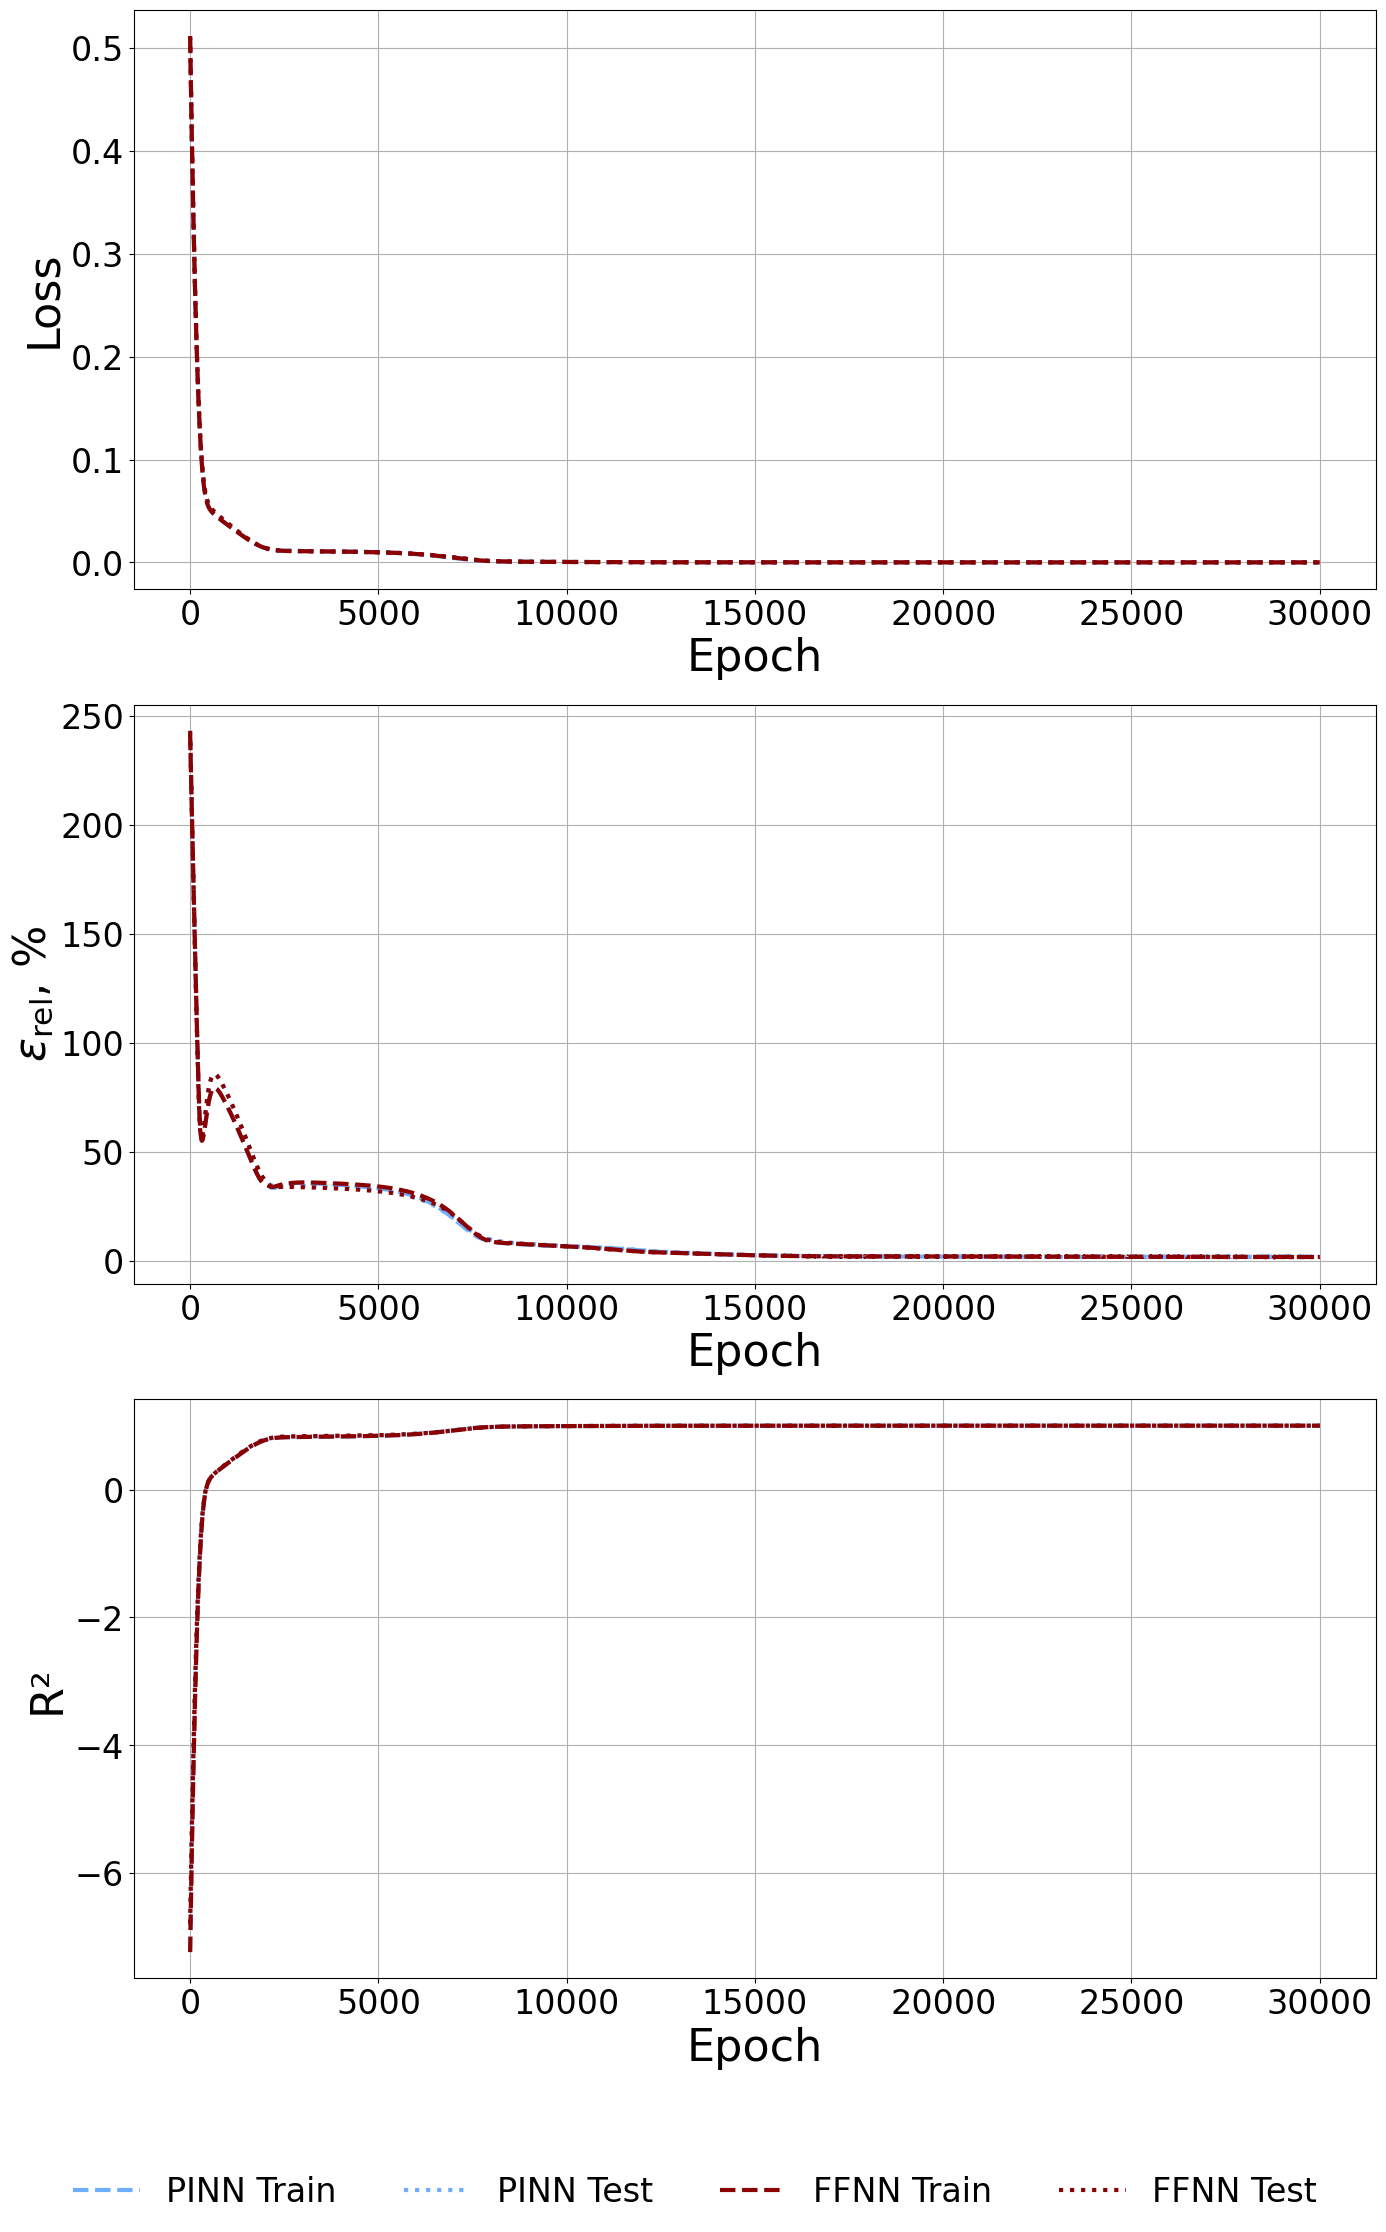

In [28]:
col_blue = '#6FAEFF'
col_red = '#8B0000'
# col_blue =  '#9E9E9E'  # тёмно-серый (PINN)
# col_red  = '#2B2B2B'

epochs = (range(len(history["train_loss"])))

# создаём фигуру
fig, axs = plt.subplots(3, 1, figsize=(14, 22))

# ----------------- PLOT 1 -----------------
axs[0].plot(epochs, history["train_loss"], ls="--", color=col_blue, linewidth=3, label='PINN Train')
axs[0].plot(epochs, history["test_loss"], ls=":", color=col_blue, linewidth=3, label='PINN Test')

axs[0].plot(epochs, history_no_phys["train_loss"], ls="--", color=col_red, linewidth=3, label='FFNN Train')
axs[0].plot(epochs, history_no_phys["test_loss"], ls=":", color=col_red, linewidth=3, label='FFNN Test')

axs[0].set_xlabel("Epoch", fontsize=32)
axs[0].set_ylabel("Loss", fontsize=32)
axs[0].tick_params(labelsize=24)
axs[0].grid(True)

# ----------------- PLOT 2 -----------------
axs[1].plot(epochs, history["train_re"], ls="--", color=col_blue, linewidth=3, label='PINN Train')
axs[1].plot(epochs, history["test_re"], ls=":", color=col_blue, linewidth=3, label='PINN Test')

axs[1].plot(epochs, history_no_phys["train_re"], ls="--", color=col_red, linewidth=3, label='FFNN Train')
axs[1].plot(epochs, history_no_phys["test_re"], ls=":", color=col_red, linewidth=3, label='FFNN Test')

axs[1].set_xlabel("Epoch", fontsize=32)
axs[1].set_ylabel(r"$\varepsilon_{\mathrm{rel}}$, %", fontsize=32)

axs[1].tick_params(labelsize=24)
axs[1].grid(True)

# ----------------- PLOT 3 -----------------
axs[2].plot(epochs, history["train_r2"], ls="--", color=col_blue, linewidth=3, label='PINN Train')
axs[2].plot(epochs, history["test_r2"], ls=":", color=col_blue, linewidth=3, label='PINN Test')

axs[2].plot(epochs, history_no_phys["train_r2"], ls="--", color=col_red, linewidth=3, label='FFNN Train')
axs[2].plot(epochs, history_no_phys["test_r2"], ls=":", color=col_red, linewidth=3, label='FFNN Test')

axs[2].set_xlabel("Epoch", fontsize=32)
axs[2].set_ylabel("R²", fontsize=32)
axs[2].tick_params(labelsize=24)
axs[2].grid(True)

# собираем легенду из первого subplot
handles, labels = axs[0].get_legend_handles_labels()

# Одна общая легенда
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    fontsize=24,
    ncol=4,          # в одну строку
    frameon=False
)

# место под легенду
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(hspace=0.2)

plt.show()


### 6.5. Сравнение предсказаний и истинных значений перепада давления (PINN vs FFNN)

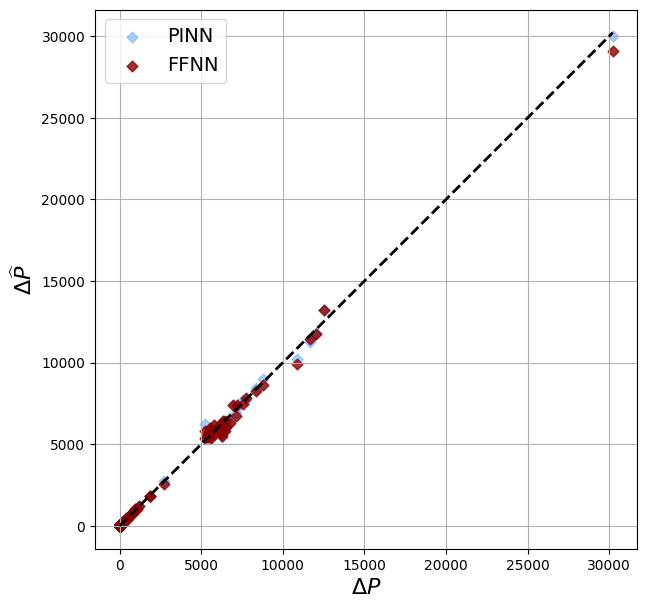

In [29]:
plt.figure(figsize=(7, 7))

# pinn
plt.scatter(
    (y/1).ravel(),
    (y_pinn/1).ravel(),
    alpha=0.6,
    color=col_blue,
    marker='D',
    s=30,
    label='PINN'
)

# ffnn
plt.scatter(
    (y/1).ravel(),
    (y_ffnn/1).ravel(),
    alpha=0.8,
    color=col_red,
    marker='D',
    s=30,
    label='FFNN'
)

min_val = min((y/1).min(), (y_pinn/1).min(), (y_ffnn/1).min())
max_val = max((y/1).max(), (y_pinn/1).max(), (y_ffnn/1).max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)

plt.xlabel(r"$\Delta P$", fontsize=16)
plt.ylabel(r"$\Delta \widehat{P}$", fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.axis("equal")
plt.legend(fontsize=14)
plt.show()

In [30]:
df

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry,Pressure difference
0,30,5.0,0.0,1.0,8.314286
1,50,5.0,0.0,1.0,4.813714
2,100,5.0,0.0,1.0,2.422286
3,200,5.0,0.0,1.0,1.201500
4,300,5.0,0.0,1.0,0.804857
...,...,...,...,...,...
1795,400,2.5,0.9,0.0,5233.191107
1796,500,2.5,0.9,0.0,5190.653726
1797,600,2.5,0.9,0.0,5374.132286
1798,700,2.5,0.9,0.0,5238.718373


## 7. Проверка на независимом тестовом наборе данных

### 7.1. Загрузка и очистка данных внешнего тестирования

In [31]:
# Читаем набор данных в df_test
df_test = pd.read_csv("../data/data_test2.csv", sep=",")
df_test.columns = [c.strip() for c in df_test.columns]

feature_cols = ["Re", "Stenosis length/Radius", "Degree of stenosis", "Asymmetry"]
target_col = "Pressure difference"


### 7.2. Загрузка обученных моделей и скейлеров

In [32]:
# pinn
scaler_X_pinn = joblib.load("../models/pinn/scaler_X_pinn.pkl")
scaler_y_pinn = joblib.load("../models/pinn/scaler_y_pinn.pkl")

model_pinn = SimplePINN()
model_pinn.load_state_dict(torch.load("../models/pinn/pinn_model.pth", map_location="cpu"))
model_pinn.eval()

# ffnn
scaler_X_ffnn = joblib.load("../models/ffnn/scaler_X_ffnn.pkl")
scaler_y_ffnn = joblib.load("../models/ffnn/scaler_y_ffnn.pkl")

model_ffnn = SimplePINN()
model_ffnn.load_state_dict(torch.load("../models/ffnn/ffnn_model.pth", map_location="cpu"))
model_ffnn.eval()

SimplePINN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

### 7.3. Препроцессинг входов и постпроцессинг предсказаний

In [33]:
def preprocess_X(X_raw: np.ndarray) -> np.ndarray:
    X = X_raw.astype(np.float32).copy()
    if np.any(X[:, 0] <= 0):
        raise ValueError("Re должно быть > 0, иначе log(Re) не определён.")
    X[:, 0] = np.log(X[:, 0])  # log(Re)
    return X

def postprocess_y_nd(y_scaled: np.ndarray, scaler_y) -> np.ndarray:
    # scaled -> log1p(y_nd)
    y_log = scaler_y.inverse_transform(y_scaled.reshape(-1, 1))

    # log1p(y_nd) -> y_nd
    y_nd = np.expm1(y_log)

    return y_nd.reshape(-1, 1)

### 7.4. Функции предсказания перепада давления (PINN и FFNN)

In [34]:
@torch.no_grad()
def predict_pinn_nd(X_raw: np.ndarray) -> np.ndarray:
    X_log = preprocess_X(X_raw)
    X_scaled = scaler_X_pinn.transform(X_log).astype(np.float32)
    y_scaled = model_pinn(torch.from_numpy(X_scaled)).cpu().numpy()
    return postprocess_y_nd(y_scaled, scaler_y_pinn)

@torch.no_grad()
def predict_ffnn_nd(X_raw: np.ndarray) -> np.ndarray:
    X_log = preprocess_X(X_raw)
    X_scaled = scaler_X_ffnn.transform(X_log).astype(np.float32)
    y_scaled = model_ffnn(torch.from_numpy(X_scaled)).cpu().numpy()
    return postprocess_y_nd(y_scaled, scaler_y_ffnn)

In [35]:
X_raw_test = df_test[feature_cols].to_numpy(dtype=np.float32)

# истинное безразмерное ΔP
y_true_nd = df_test[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

# предсказания
y_pinn_nd = predict_pinn_nd(X_raw_test)
y_ffnn_nd = predict_ffnn_nd(X_raw_test)

### 7.5. Оценка качества и визуализация

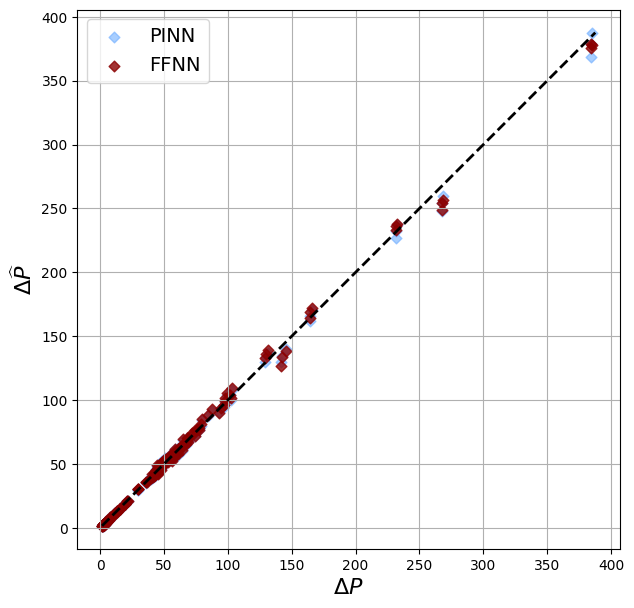

In [36]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_true_nd, y_pinn_nd,
    alpha=0.6, color=col_blue, marker='D', s=30, label='PINN'
)
plt.scatter(
    y_true_nd, y_ffnn_nd,
    alpha=0.8, color=col_red, marker='D', s=30, label='FFNN'
)

min_val = min(y_true_nd.min(), y_pinn_nd.min(), y_ffnn_nd.min())
max_val = max(y_true_nd.max(), y_pinn_nd.max(), y_ffnn_nd.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)

plt.xlabel(r"$\Delta P$", fontsize=16)
plt.ylabel(r"$\Delta \widehat{P}$", fontsize=16)
plt.grid(True)
plt.axis("equal")
plt.legend(fontsize=14)
plt.show()


In [37]:
eps = 1e-8

# относительная ошибка по каждому примеру
rel_err_pinn = np.abs(y_pinn_nd - y_true_nd) / (np.abs(y_true_nd) + eps) * 100
rel_err_ffnn = np.abs(y_ffnn_nd - y_true_nd) / (np.abs(y_true_nd) + eps) * 100

df_test["y_true_nd"] = y_true_nd.ravel()
df_test["y_pinn_nd"] = y_pinn_nd.ravel()
df_test["y_ffnn_nd"] = y_ffnn_nd.ravel()

df_test["rel_err_pinn_%"] = rel_err_pinn.ravel()
df_test["rel_err_ffnn_%"] = rel_err_ffnn.ravel()

In [38]:
def calc_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    r2 = 1 - np.sum((y_true - y_pred)**2) / (np.sum((y_true - y_true.mean())**2) + eps)
    wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100
    mae_over_std = np.mean(np.abs(y_true - y_pred)) / (np.std(y_true, ddof=1) + eps) * 100
    mae_over_mean = np.mean(np.abs(y_true - y_pred)) / (np.mean(np.abs(y_true)) + eps) * 100
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), eps)) * 100

    return {
        "R²": r2,
        "WAPE": wape,
        "sMAPE": smape,
        "MAE/std(y)": mae_over_std,
        "MAE/mean|y|": mae_over_mean,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
    }

metrics_pinn = calc_metrics(y_true_nd, y_pinn_nd, eps)
metrics_ffnn = calc_metrics(y_true_nd, y_ffnn_nd, eps)

print("-----------------------------------------------------")
print(f"{'Метрика':<15} | {'PINN':^15} | {'FFNN':^15}")
print("-----------------------------------------------------")
print(f"{'R²':<15} | {metrics_pinn['R²']:>15.6f} | {metrics_ffnn['R²']:>15.6f}")
print(f"{'WAPE':<15} | {metrics_pinn['WAPE']:>14.2f}% | {metrics_ffnn['WAPE']:>14.2f}%")
print(f"{'sMAPE':<15} | {metrics_pinn['sMAPE']:>14.2f}% | {metrics_ffnn['sMAPE']:>14.2f}%")
print(f"{'MAE/std(y)':<15} | {metrics_pinn['MAE/std(y)']:>14.2f}% | {metrics_ffnn['MAE/std(y)']:>14.2f}%")
print(f"{'MAE/mean|y|':<15} | {metrics_pinn['MAE/mean|y|']:>14.2f}% | {metrics_ffnn['MAE/mean|y|']:>14.2f}%")
print("-----------------------------------------------------")
print(f"{'MAPE':<15} | {metrics_pinn['MAPE']:>14.2f}% | {metrics_ffnn['MAPE']:>14.2f}%")
print(f"{'RMSE':<15} | {metrics_pinn['RMSE']:>15.6f} | {metrics_ffnn['RMSE']:>15.6f}")
print(f"{'MAE':<15} | {metrics_pinn['MAE']:>15.6f} | {metrics_ffnn['MAE']:>15.6f}")
print("-----------------------------------------------------")

-----------------------------------------------------
Метрика         |      PINN       |      FFNN      
-----------------------------------------------------
R²              |        0.998153 |        0.997909
WAPE            |           2.96% |           3.20%
sMAPE           |           4.74% |           4.97%
MAE/std(y)      |           2.19% |           2.36%
MAE/mean|y|     |           2.96% |           3.20%
-----------------------------------------------------
MAPE            |           4.58% |           4.80%
RMSE            |        2.656022 |        2.825449
MAE             |        1.354216 |        1.464466
-----------------------------------------------------


In [39]:
df_test[[
    "Re", "Stenosis length/Radius", "Degree of stenosis", "Asymmetry",
    "y_true_nd", "y_pinn_nd", "y_ffnn_nd",
    "rel_err_pinn_%", "rel_err_ffnn_%"
]]

,Re,Stenosis length/Radius,Degree of stenosis,Asymmetry,y_true_nd,y_pinn_nd,y_ffnn_nd,rel_err_pinn_%,rel_err_ffnn_%
0,30,8,0.33,1.0,19.799999,19.211544,18.753798,2.971996,5.283847
1,50,8,0.33,1.0,11.880000,11.525973,11.418813,2.980023,3.882049
2,100,8,0.33,1.0,6.642000,6.288927,6.211756,5.315765,6.477634
3,200,8,0.33,1.0,4.080857,3.850506,3.749480,5.644683,8.120292
4,300,8,0.33,1.0,3.300000,3.065968,2.974719,7.091876,9.857004
...,...,...,...,...,...,...,...,...,...
235,400,25,0.66,0.0,58.737053,61.279888,61.926434,4.329184,5.429930
236,500,25,0.66,0.0,55.007484,56.604477,57.252354,2.903228,4.081025
237,600,25,0.66,0.0,51.620998,53.418468,54.152248,3.482052,4.903528
238,700,25,0.66,0.0,50.491573,51.091038,51.954967,1.187256,2.898294


Проверка частных случаев

In [40]:
# Re=300, L/R=16, stenosis=0.55, asym=0
x_one = np.array([[800, 10, 0.55, 0.0]], dtype=np.float32)

y_pinn_one = predict_pinn_nd(x_one)
y_ffnn_one = predict_ffnn_nd(x_one)

print("PINN prediction (ΔP*):", float(y_pinn_one[0, 0]))
print("FFNN prediction (ΔP*):", float(y_ffnn_one[0, 0]))

PINN prediction (ΔP*): 12.951552391052246
FFNN prediction (ΔP*): 13.03510570526123


In [41]:
# Re=300, L/R=16, stenosis=0.55, asym=0
x_one = np.array([[366, 16, 0.7, 0]], dtype=np.float32)

y_pinn_one = predict_pinn_nd(x_one)
y_ffnn_one = predict_ffnn_nd(x_one)

print("PINN prediction (ΔP*):", float(y_pinn_one[0, 0]))
print("FFNN prediction (ΔP*):", float(y_ffnn_one[0, 0]))

PINN prediction (ΔP*): 89.81053161621094
FFNN prediction (ΔP*): 89.50770568847656
